In [ ]:
import sys
from pathlib import Path

raiz_projeto = Path().resolve().parents[1]
if str(raiz_projeto) not in sys.path:
    sys.path.append(str(raiz_projeto))

from utils.raster import calcular_classes_mascara


In [ ]:
import glob
import os
import random

import numpy as np
import pandas as pd
import rasterio


## Utils

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import rasterio

def visualizar_mascara(tif_path, figsize=(8, 8)):
    with rasterio.open(tif_path) as src:
        mask = src.read(1)

    # Classes presentes
    classes = np.unique(mask)

    # Reindexa as classes para 0,1,2,...
    idx = {c: i for i, c in enumerate(classes)}
    mask_plot = np.vectorize(idx.get)(mask)

    # Uma cor por classe
    # cmap = ListedColormap(plt.cm.tab20.colors[:len(classes)])

    plt.figure(figsize=figsize)
    im = plt.imshow(mask_plot, cmap="gray", interpolation="nearest")

    # # Barra de cores mostrando os valores reais das classes
    # cbar = plt.colorbar(im, ticks=np.arange(len(classes)))
    # cbar.ax.set_yticklabels(classes)

    plt.axis("off")
    plt.title("Máscara")
    plt.show()

## Get Images

In [47]:
reservoirs = [f for f in os.listdir("D:/GeoPipe/data/03_cloud_masks") if not '.' in f]

In [48]:
reservoirs

['argemiro', 'engenheiro_avidos', 'gramame', 'lagoa_do_arroz', 'mares', 'sume']

In [49]:
images = []

for reservoir in reservoirs:
    images += glob.glob(f"D:/GeoPipe/data/03_cloud_masks/{reservoir}/fmask/**/*.tif")

In [50]:
len(images)

4049

In [51]:
images[:5]

['D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2017\\mask_sentinel_TOA_S2_argemiro_20170103.tif',
 'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2017\\mask_sentinel_TOA_S2_argemiro_20170123.tif',
 'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2017\\mask_sentinel_TOA_S2_argemiro_20170202.tif',
 'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2017\\mask_sentinel_TOA_S2_argemiro_20170212.tif',
 'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2017\\mask_sentinel_TOA_S2_argemiro_20170304.tif']

## One image test

In [52]:
with rasterio.open(images[0]) as src:
    print("NoData:", src.nodata)

    mask = src.read(1)

    classes, counts = np.unique(mask, return_counts=True)
    print(dict(zip(classes, counts)))

NoData: 0.0
{0: 147330, 1: 1438924, 2: 3254}


In [53]:
random_image = random.choice(images)
calcular_classes_mascara(random_image)

{0: {'pixels': 729368, 'percentual': 45.88640006844885},
 1: {'pixels': 653264, 'percentual': 41.09850343628343},
 2: {'pixels': 206876, 'percentual': 13.015096495267716}}

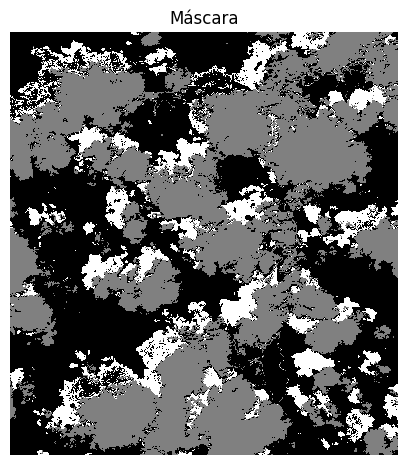

In [54]:
visualizar_mascara(random_image, figsize=(5, 10))

## Generate Dataframe

In [55]:
images_dicts = []

for image in images:
    line = {}
    classes_info = calcular_classes_mascara(image)
    line["image"] = image
    line['cloud_pixels'] = classes_info.get(1, {}).get("percentual", 0)
    line['cloud_shadow_pixels'] = classes_info.get(2, {}).get("percentual", 0)
    images_dicts.append(line)
    print(f"Image: {image}")


Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170103.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170123.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170202.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170212.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170304.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170413.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170503.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170523.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170612.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_201

In [56]:
images_df = pd.DataFrame(images_dicts)

In [57]:
images_df[:5]

,image,cloud_pixels,cloud_shadow_pixels
0,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,90.526377,0.204717
1,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,58.810714,10.466761
2,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,22.261857,10.614605
3,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,92.981036,0.014722
4,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,32.915657,5.351845


In [58]:
images_df["reservoir"] = images_df["image"].apply(lambda x: x.split("/")[4])

In [59]:
images_df[:5]

,image,cloud_pixels,cloud_shadow_pixels,reservoir
0,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,90.526377,0.204717,argemiro
1,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,58.810714,10.466761,argemiro
2,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,22.261857,10.614605,argemiro
3,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,92.981036,0.014722,argemiro
4,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,32.915657,5.351845,argemiro


In [60]:
# rename columns
images_df.rename(columns={
    "image": "mask",
    "cloud_pixels": "cloud_percentage",
    "cloud_shadow_pixels": "cloud_shadow_percentage"
}, inplace=True)

## Get Corresponding BOA image

In [61]:
images = []

for reservoir in reservoirs:
    images += glob.glob(f"D:/GeoPipe/data/02_boa_images/{reservoir}/**/*.tif")

In [62]:
images[:5]

['D:/GeoPipe/data/02_boa_images/argemiro\\2018\\sentinel_BOA_S2_SR_argemiro_20180612.tif',
 'D:/GeoPipe/data/02_boa_images/argemiro\\2018\\sentinel_BOA_S2_SR_argemiro_20181214.tif',
 'D:/GeoPipe/data/02_boa_images/argemiro\\2018\\sentinel_BOA_S2_SR_argemiro_20181219.tif',
 'D:/GeoPipe/data/02_boa_images/argemiro\\2018\\sentinel_BOA_S2_SR_argemiro_20181224.tif',
 'D:/GeoPipe/data/02_boa_images/argemiro\\2018\\sentinel_BOA_S2_SR_argemiro_20181229.tif']

In [63]:
from pathlib import Path
import pandas as pd
import re

import re

pattern = re.compile(
    r".*_(?P<area>[^_]+)_(?P<date>\d{8})\.tif$",
    re.IGNORECASE
)

def make_key(path):
    path = path.replace("\\", "/")
    m = pattern.search(path)
    if m is None:
        return None
    return m.group("area"), m.group("date")


def add_image_path(df: pd.DataFrame,
                   mask_column: str,
                   image_paths: list[str],
                   missing_value=None) -> pd.DataFrame:
    """
    Adiciona ao dataframe uma coluna 'image_path' contendo o caminho
    da imagem correspondente à máscara.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contendo os paths das máscaras.
    mask_column : str
        Nome da coluna com os paths das máscaras.
    image_paths : list[str]
        Lista dos paths das imagens.
    missing_value : any
        Valor para imagens não encontradas (default=None).

    Returns
    -------
    pd.DataFrame
    """

    # índice das imagens
    image_dict = {
        make_key(img): img
        for img in image_paths
    }

    # cria a coluna
    df = df.copy()
    df["image_path"] = (
        df[mask_column]
        .map(lambda x: image_dict.get(make_key(x), missing_value))
    )

    return df

In [64]:
df = add_image_path(
    df=images_df,
    mask_column="mask",
    image_paths=images,
    missing_value=pd.NA
)

In [65]:
df

,mask,cloud_percentage,cloud_shadow_percentage,reservoir,image_path
0,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,90.526377,0.204717,argemiro,<NA>
1,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,58.810714,10.466761,argemiro,<NA>
2,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,22.261857,10.614605,argemiro,<NA>
3,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,92.981036,0.014722,argemiro,<NA>
4,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,32.915657,5.351845,argemiro,<NA>
...,...,...,...,...,...
4044,D:/GeoPipe/data/03_cloud_masks/sume/fmask\2026...,97.036333,1.871017,sume,D:/GeoPipe/data/02_boa_images/sume\2026\sentin...
4045,D:/GeoPipe/data/03_cloud_masks/sume/fmask\2026...,0.890802,2.282721,sume,D:/GeoPipe/data/02_boa_images/sume\2026\sentin...
4046,D:/GeoPipe/data/03_cloud_masks/sume/fmask\2026...,100.000000,0.000000,sume,D:/GeoPipe/data/02_boa_images/sume\2026\sentin...
4047,D:/GeoPipe/data/03_cloud_masks/sume/fmask\2026...,98.407233,0.147800,sume,D:/GeoPipe/data/02_boa_images/sume\2026\sentin...


In [66]:
df[500:505]['mask'].to_list(), df[500:505]['image_path'].to_list()

(['D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2024\\mask_sentinel_TOA_S2_argemiro_20241217.tif',
  'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2024\\mask_sentinel_TOA_S2_argemiro_20241222.tif',
  'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2024\\mask_sentinel_TOA_S2_argemiro_20241227.tif',
  'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2025\\mask_sentinel_TOA_S2_argemiro_20250101.tif',
  'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2025\\mask_sentinel_TOA_S2_argemiro_20250106.tif'],
 ['D:/GeoPipe/data/02_boa_images/argemiro\\2024\\sentinel_BOA_S2_SR_argemiro_20241217.tif',
  'D:/GeoPipe/data/02_boa_images/argemiro\\2024\\sentinel_BOA_S2_SR_argemiro_20241222.tif',
  'D:/GeoPipe/data/02_boa_images/argemiro\\2024\\sentinel_BOA_S2_SR_argemiro_20241227.tif',
  'D:/GeoPipe/data/02_boa_images/argemiro\\2025\\sentinel_BOA_S2_SR_argemiro_20250101.tif',
  'D:/GeoPipe/data/02_boa_images/argemiro\\2025\\sentinel_BOA_S2_SR_argemiro_20250106.tif'])

In [67]:
df.dropna(subset=["image_path"], inplace=True)

In [68]:
len(df)

3561

In [69]:
imagess = []

for reservoir in reservoirs:
    imagess += glob.glob(f"D:/GeoPipe/data/04_clean_images/{reservoir}/fmask/**/**/*.tif")

In [70]:
len(imagess)

3506

## Filter cloud free images

In [71]:
df.describe()

,cloud_percentage,cloud_shadow_percentage
count,3561.000000,3561.000000
mean,50.132411,4.758198
std,37.622545,5.190225
min,0.000000,0.000000
25%,12.686768,0.344725
50%,45.088020,3.351016
75%,92.523173,7.543088
max,100.000000,58.863526


In [72]:
for percentage in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
    count = len(df.loc[df['cloud_percentage'] <= percentage])
    print(f"Cloud percentage <= {percentage}%: {count} images")

Cloud percentage <= 0%: 5 images
Cloud percentage <= 10%: 806 images
Cloud percentage <= 20%: 1084 images
Cloud percentage <= 30%: 1372 images
Cloud percentage <= 40%: 1644 images
Cloud percentage <= 50%: 1886 images
Cloud percentage <= 60%: 2075 images
Cloud percentage <= 70%: 2239 images
Cloud percentage <= 80%: 2403 images
Cloud percentage <= 90%: 2610 images
Cloud percentage <= 100%: 3561 images


In [73]:
df_cloud_free = df.loc[df['cloud_percentage'] <= 10]

In [74]:
print("Quantidade de imagens por reservatório com nuvens <= 10%:")
images_cloud_free_count = {}
for reservoir in df_cloud_free['reservoir'].unique():
    count = df_cloud_free[df_cloud_free['reservoir'] == reservoir].shape[0]
    images_cloud_free_count[reservoir] = count
    print(f"  {reservoir}: {count}")

Quantidade de imagens por reservatório com nuvens <= 10%:
  argemiro: 31
  engenheiro_avidos: 236
  gramame: 8
  lagoa_do_arroz: 252
  mares: 61
  sume: 218


In [75]:
# Get imagens with cloud_percentage > 0 and <= 50
masks = df.loc[(df['cloud_percentage'] > 0) & (df['cloud_percentage'] <= 50)]

In [76]:
# rename with sufix all fields names
masks = masks.rename(columns=lambda x: f"random_{x}" if isinstance(x, (int, float, str)) else x)

In [77]:
masks.describe()

,random_cloud_percentage,random_cloud_shadow_percentage
count,1881.000000,1881.000000
mean,18.091089,7.147697
std,15.896843,5.332329
min,0.000092,0.000000
25%,2.391682,3.224682
50%,14.230503,6.268911
75%,31.772705,9.766790
max,49.973309,58.863526


In [78]:
masks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1881 entries, 46 to 4048
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   random_mask                     1881 non-null   object 
 1   random_cloud_percentage         1881 non-null   float64
 2   random_cloud_shadow_percentage  1881 non-null   float64
 3   random_reservoir                1881 non-null   object 
 4   random_image_path               1881 non-null   object 
dtypes: float64(2), object(3)
memory usage: 88.2+ KB


In [79]:
masks_sample = pd.DataFrame()

for reservoir in reservoirs:
    masks_sample = pd.concat([
        masks_sample,
        masks[masks['random_reservoir'] == reservoir].sample(n=images_cloud_free_count[reservoir], random_state=42)
    ])

In [80]:
masks_sample = masks_sample.drop(columns=['random_reservoir', 'random_image_path'])


In [81]:
for reservoir in df_cloud_free['reservoir'].unique():
    count = df_cloud_free[df_cloud_free['reservoir'] == reservoir].shape[0]
    print(f"  {reservoir}: {count}")

  argemiro: 31
  engenheiro_avidos: 236
  gramame: 8
  lagoa_do_arroz: 252
  mares: 61
  sume: 218


In [82]:
print(masks_sample.shape, df_cloud_free.shape)

(806, 3) (806, 5)


In [83]:
df1 = df_cloud_free.reset_index(drop=True)
df2 = masks_sample.reset_index(drop=True)
final_df = pd.concat([df1, df2], axis=1)

In [84]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   mask                            806 non-null    object 
 1   cloud_percentage                806 non-null    float64
 2   cloud_shadow_percentage         806 non-null    float64
 3   reservoir                       806 non-null    object 
 4   image_path                      806 non-null    object 
 5   random_mask                     806 non-null    object 
 6   random_cloud_percentage         806 non-null    float64
 7   random_cloud_shadow_percentage  806 non-null    float64
dtypes: float64(4), object(4)
memory usage: 50.5+ KB


In [85]:
final_df.describe()

,cloud_percentage,cloud_shadow_percentage,random_cloud_percentage,random_cloud_shadow_percentage
count,806.000000,806.000000,806.000000,806.000000
mean,2.764633,4.408699,14.941298,6.753650
std,3.152053,4.356474,15.460870,5.656926
min,0.000000,0.000000,0.000092,0.015014
25%,0.035268,1.897323,0.823949,2.687335
50%,1.292323,3.281106,9.382245,5.548317
75%,5.272666,5.470119,27.664481,9.167830
max,9.999133,58.863526,49.904436,58.863526


In [86]:
final_df.to_csv("../data/temporal_interpolation_images.csv", index=False)